In [ ]:
# 1. Unduh repositori tim NoteScanin dari GitHub
!rm -rf ai
!git clone https://github.com/NoteScanin/ai.git

# 2. Install dependensi gambar dan pemrosesan teks esensial secara manual
!pip install opencv-python-headless pillow diffimg arabic-reshaper python-bidi wikipedia

# 3. Install TRDG langsung dari source Git resmi yang kompatibel dengan Python 3.12
!pip install git+https://github.com/Belval/TextRecognitionDataGenerator.git --no-deps

# 4. Tambahkan Pustaka Utama untuk TrOCR (Transformers & Akselerator GPU)
!pip install transformers datasets accelerate -q

# 5. Ekstrak Berkas Font NoteScanin ke Folder 'font'
!unzip -q "NoteScanin ai main hw_fonts.zip" -d font

Cloning into 'ai'...
remote: Enumerating objects: 18543, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 18543 (delta 0), reused 0 (delta 0), pack-reused 18540 (from 4)
Receiving objects: 100% (18543/18543), 631.66 MiB | 36.74 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Updating files: 100% (18517/18517), done.
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 14.2 MB/s eta 0:00:00
  Created wheel for diffimg: filename=diffimg-0.3.0-py3-none-any.whl size=4180 sha256=54b64104612488cefff75d028867234603b76e69fe197d9fd085fe073dd2c221
  Stored in directory: /root/.cache/pip/wheels/07/da/68/6c98671295b132744758c218cb6b1a79655486428335d6743e
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=680344daaa323942d42c1f9596ff84450533b0c90686f039e346d85813cdd0e8
  Stored in directory: /root/.cache/pip/wh

In [ ]:
import os
import glob
import random
import pandas as pd
import torch
from torch.utils.data import Dataset
from trdg.generators import GeneratorFromStrings

class OnTheFlyTRDGDataset(Dataset):
    def __init__(self, tsv_path, fonts_dir, processor, max_target_length=32):
        # 1. Membaca korpus data teks NoteScanin
        self.df = pd.read_csv(
            tsv_path, sep="\t", header=None, names=["id", "lang", "text"], quoting=3, on_bad_lines="skip"
        )
        self.df = self.df[self.df["id"] != "id"].reset_index(drop=True)

        # 2. Ambil list berkas font tulisan tangan
        self.all_fonts = glob.glob(os.path.join(fonts_dir, "*.ttf")) + glob.glob(os.path.join(fonts_dir, "*.otf"))
        if not self.all_fonts:
            raise FileNotFoundError(f"Tidak ada font ditemukan di folder {fonts_dir}")

        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text_label = str(row["text"])

        # Pilih font secara acak
        selected_font = random.choice(self.all_fonts)

        # Generator TRDG untuk render gambar teks on-the-fly
        gen = GeneratorFromStrings(
            [text_label],
            fonts=[selected_font],
            skewing_angle=random.randint(0, 1),
            size=64,
            fit=True,
        )
        img, _ = next(iter(gen))

        # A. Ekstrak Fitur Gambar (Menghasilkan Pixel Values)
        pixel_values = self.processor(images=img, return_tensors="pt").pixel_values

        # B. Tokenisasi Teks (PERBAIKAN UTAMA: Menggunakan pemanggilan text langsung pada processor)
        labels = self.processor(
            text=text_label,
            padding="max_length",
            truncation=True,
            max_length=self.max_target_length,
            return_tensors="pt"
        ).input_ids.squeeze(0)  # Squeeze langsung di sini agar dimensi bersih menjadi [32]

        # C. Siasati token padding agar bernilai -100 (agar diabaikan oleh Loss Function)
        labels = torch.tensor([
            token if token != self.processor.tokenizer.pad_token_id else -100
            for token in labels
        ], dtype=torch.long)

        return {
            "pixel_values": pixel_values.squeeze(0),
            "labels": labels
        }

In [ ]:
# 1. Ekstrak zip ke dalam folder bernama 'font'
!unzip -q "NoteScanin ai main hw_fonts.zip" -d font

# 2. Cek apakah foldernya sudah muncul dan berisi file font (.ttf/.otf)
!ls font

replace font/CedarvilleCursive-Regular.ttf? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
BadScript-Regular.ttf	       JustAnotherHand-Regular.ttf
behance-66790c0a8c808.otf      Kristi-Regular.ttf
Caveat-VariableFont_wght.ttf   LaBelleAurore-Regular.ttf
CedarvilleCursive-Regular.ttf  NothingYouCouldDo-Regular.ttf
DawningofaNewDay-Regular.ttf   ReenieBeanie-Regular.ttf
GloriaHallelujah-Regular.ttf   SeaweedScript-Regular.ttf
HomemadeApple-Regular.ttf


In [ ]:
import os
from torch.utils.data import DataLoader
from transformers import TrOCRProcessor

# 1. Panggil dulu processor resmi TrOCR sebelum membuat dataset
# Komponen ini wajib dioper ke dalam dataset agar gambar & teks otomatis ter-tokenisasi
MODEL_NAME = "microsoft/trocr-small-handwritten"
processor = TrOCRProcessor.from_pretrained(MODEL_NAME)

# 2. Inisialisasi Dataset dengan menambahkan argumen processor=processor
dataset_train = OnTheFlyTRDGDataset(
    tsv_path="corpus_1.tsv",
    fonts_dir="font",
    processor=processor  # <--- WAJIB DITAMBAHKAN UNTUK TrOCR
)

# 3. Deteksi otomatis jumlah core CPU Colab untuk multithreading
ideal_workers = os.cpu_count() or 2

# 4. Setel DataLoader dengan batch_size yang aman untuk vRAM T4 GPU
train_loader = DataLoader(
    dataset_train,
    batch_size=8,               # PERBAIKAN: Dari 64 diganti ke 8/16 agar vRAM T4 GPU tidak OOM
    shuffle=True,
    num_workers=ideal_workers,  # Ditingkatkan agar rendering TRDG berjalan paralel
    pin_memory=True,            # Setel True jika kamu training menggunakan GPU/CUDA
    drop_last=True              # Abaikan sisa data yang tidak genap agar ukuran batch konsisten
)

print(f"✓ DataLoader berhasil dikonfigurasi dengan {ideal_workers} workers!")

preprocessor_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.21k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/327 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

✓ DataLoader berhasil dikonfigurasi dengan 2 workers!


In [ ]:
import os
import glob
import random
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from trdg.generators import GeneratorFromStrings
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

# ==============================================================================
# 1. DEFINISI DATASET ON-THE-FLY YANG SUDAH TERINTEGRASI DENGAN PROCESSOR TrOCR
# ==============================================================================
class OnTheFlyTRDGDataset(Dataset):
    def __init__(self, tsv_path, fonts_dir, processor, max_target_length=32):
        # Membaca file korpus teks
        self.df = pd.read_csv(
            tsv_path, sep="\t", header=None, names=["id", "lang", "text"], quoting=3, on_bad_lines="skip"
        )
        # Saring baris jika header terekam sebagai data
        self.df = self.df[self.df["id"] != "id"].reset_index(drop=True)

        # Ambil semua file font tulisan tangan
        self.all_fonts = glob.glob(os.path.join(fonts_dir, "*.ttf")) + glob.glob(os.path.join(fonts_dir, "*.otf"))
        if not self.all_fonts:
            raise FileNotFoundError(f"Tidak ada font ditemukan di folder {fonts_dir}")

        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text_label = str(row["text"])

        # Pilih font acak
        selected_font = random.choice(self.all_fonts)

        # Render gambar menggunakan TRDG
        gen = GeneratorFromStrings(
            [text_label],
            fonts=[selected_font],
            skewing_angle=random.randint(0, 1),
            size=64,
            fit=True,
        )
        img, _ = next(iter(gen))

        #--- PROSES PENGUBAHAN JALUR KE TRANSFORMER ---
        # A. Ekstrak Fitur Gambar menjadi Pixel Values
        pixel_values = self.processor(images=img, return_tensors="pt").pixel_values

        # B. Tokenisasi teks target (PERBAIKAN: Ditambahkan truncation=True agar ukuran terkunci mati)
        labels = self.processor.tokenizer(
            text_label,
            return_tensors="pt",
            padding="max_length",
            truncation=True,             # <--- KUNCI PENYELAMAT AGAR UKURAN TENSOR KONSISTEN
            max_length=self.max_target_length
        ).input_ids

        # C. Ubah token padding (0) menjadi -100 agar diabaikan oleh Loss PyTorch secara otomatis
        labels = [tuple(label if label != self.processor.tokenizer.pad_token_id else -100 for label in labels[0])]

        return {
            "pixel_values": pixel_values.squeeze(0),
            "labels": torch.tensor(labels).squeeze(0)
        }


# ==============================================================================
# 2. KONFIGURASI HYPERPARAMETER & MEMUAT MODEL (T4 GPU)
# ==============================================================================
BATCH_SIZE = 8   # Direkomendasikan 8 atau 16 untuk mencegah vRAM T4 GPU Out of Memory (OOM)
LR = 5e-5        # Learning rate standar yang aman untuk fine-tuning Transformer
TOTAL_EPOCHS = 5
CHECKPOINT_DIR = "trocr_notescanin_model"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training NoteScanin akan berjalan di: {device}")

# Memanggil model dasar pretrained TrOCR-Small dari Microsoft via Hugging Face
MODEL_NAME = "microsoft/trocr-small-handwritten"
processor = TrOCRProcessor.from_pretrained(MODEL_NAME)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME).to(device)

# Setel token khusus agar struktur Encoder-Decoder bertukar informasi dengan benar
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.vocab_size = model.config.decoder.vocab_size


# ==============================================================================
# 3. SETUP DATA LOADER MULTI-WORKERS
# ==============================================================================
dataset_train = OnTheFlyTRDGDataset(tsv_path="corpus_1.tsv", fonts_dir="font", processor=processor)

ideal_workers = os.cpu_count() or 2
train_loader = DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=ideal_workers,
    pin_memory=True,
    drop_last=True
)


# ==============================================================================
# 4. OPTIMIZER & INTEGRASI FITUR RESTORE PROGRESS
# ==============================================================================
optimizer = AdamW(model.parameters(), lr=LR)
start_epoch = 0

# Jika folder checkpoint hasil epoch sebelumnya terdeteksi, muat ulang bobotnya
if os.path.exists(CHECKPOINT_DIR):
    print(f"➔ Menemukan progres model sebelumnya di '{CHECKPOINT_DIR}'. Me-restore model...")
    model = VisionEncoderDecoderModel.from_pretrained(CHECKPOINT_DIR).to(device)
    print("✓ Berhasil melanjutkan latihan dari kondisi terakhir!")
else:
    print("➔ Tidak ada checkpoint ditemukan. Memulai fine-tuning dari awal.")


# ==============================================================================
# 5. TRAINING LOOP UTAMA TrOCR
# ==============================================================================
for epoch in range(start_epoch, TOTAL_EPOCHS):
    model.train()
    running_loss = 0.0

    print(f"\n=== Epoch TrOCR {epoch+1}/{TOTAL_EPOCHS} ===")

    for batch_idx, batch in enumerate(train_loader):
        # Pindahkan tensor gambar dan target label ke memori GPU CUDA
        input_images = batch["pixel_values"].to(device)
        target_labels = batch["labels"].to(device)

        optimizer.zero_grad()

        # Forward Pass: Model Transformer otomatis menghitung Loss secara internal
        outputs = model(pixel_values=input_images, labels=target_labels)
        loss = outputs.loss

        # Backward Pass & Optimasi Bobot Jaringan
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if batch_idx % 20 == 0:
            print(f"Batch {batch_idx}/{len(train_loader)} - Loss Saat Ini: {loss.item():.4f}")

    # Mengamankan Progress Tiap Akhir Epoch
    print(f"➔ Mengamankan progres Epoch {epoch+1}...")
    model.save_pretrained(CHECKPOINT_DIR)
    processor.save_pretrained(CHECKPOINT_DIR)
    print("Folder 'trocr_notescanin_model' berhasil diperbarui!\n")

print("\n✓ Fine-Tuning TrOCR NoteScanin Selesai 100%!")

Training NoteScanin akan berjalan di: cuda


pytorch_model.bin:   0%|          | 0.00/246M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/360 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-small-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

...

Folder 'trocr_notescanin_model' berhasil diperbarui!


=== Epoch TrOCR 4/5 ===
Batch 0/3344 - Loss Saat Ini: 0.3291
Batch 20/3344 - Loss Saat Ini: 0.2406
Batch 40/3344 - Loss Saat Ini: 0.2163
Batch 60/3344 - Loss Saat Ini: 0.0781
Batch 80/3344 - Loss Saat Ini: 0.0631
Batch 100/3344 - Loss Saat Ini: 0.1152
Batch 120/3344 - Loss Saat Ini: 0.2562
Batch 140/3344 - Loss Saat Ini: 0.0825
Batch 160/3344 - Loss Saat Ini: 0.0908
Batch 180/3344 - Loss Saat Ini: 0.1569
Batch 200/3344 - Loss Saat Ini: 0.1584
Batch 220/3344 - Loss Saat Ini: 0.0700
Batch 240/3344 - Loss Saat Ini: 0.0484
Batch 260/3344 - Loss Saat Ini: 0.1054
Batch 280/3344 - Loss Saat Ini: 0.0675
Batch 300/3344 - Loss Saat Ini: 0.0152
Batch 320/3344 - Loss Saat Ini: 0.0366
Batch 340/3344 - Loss Saat Ini: 0.0366
Batch 360/3344 - Loss Saat Ini: 0.1438
Batch 380/3344 - Loss Saat Ini: 0.0126
Batch 400/3344 - Loss Saat Ini: 0.0382
Batch 420/3344 - Loss Saat Ini: 0.0775
Batch 440/3344 - Loss Saat Ini: 0.1342
Batch 460/3344 - Loss Saat Ini

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Folder 'trocr_notescanin_model' berhasil diperbarui!


=== Epoch TrOCR 5/5 ===
Batch 0/3344 - Loss Saat Ini: 0.0143
Batch 20/3344 - Loss Saat Ini: 0.0330
Batch 40/3344 - Loss Saat Ini: 0.2133
Batch 60/3344 - Loss Saat Ini: 0.0207
Batch 80/3344 - Loss Saat Ini: 0.0105
Batch 100/3344 - Loss Saat Ini: 0.1030
Batch 120/3344 - Loss Saat Ini: 0.0386
Batch 140/3344 - Loss Saat Ini: 0.1731
Batch 160/3344 - Loss Saat Ini: 0.4043
Batch 180/3344 - Loss Saat Ini: 0.2077
Batch 200/3344 - Loss Saat Ini: 0.5957
Batch 220/3344 - Loss Saat Ini: 0.2596
Batch 240/3344 - Loss Saat Ini: 0.5100
Batch 260/3344 - Loss Saat Ini: 0.1676
Batch 280/3344 - Loss Saat Ini: 0.1229
Batch 300/3344 - Loss Saat Ini: 0.1979
Batch 320/3344 - Loss Saat Ini: 0.0915
Batch 340/3344 - Loss Saat Ini: 0.0585
Batch 360/3344 - Loss Saat Ini: 0.2496
Batch 380/3344 - Loss Saat Ini: 0.2781
Batch 400/3344 - Loss Saat Ini: 0.0760
Batch 420/3344 - Loss Saat Ini: 0.0608
Batch 440/3344 - Loss Saat Ini: 0.4126
Batch 460/3344 - Loss Saat Ini

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Folder 'trocr_notescanin_model' berhasil diperbarui!


✓ Fine-Tuning TrOCR NoteScanin Selesai 100%!


In [ ]:
# Mengompres folder 'trocr_notescanin_model' menjadi file 'trocr_notescanin_model.zip'
!zip -r trocr_notescanin_model.zip trocr_notescanin_model/

  adding: trocr_notescanin_model/ (stored 0%)
  adding: trocr_notescanin_model/tokenizer.json (deflated 77%)
  adding: trocr_notescanin_model/generation_config.json (deflated 35%)
  adding: trocr_notescanin_model/tokenizer_config.json (deflated 49%)
  adding: trocr_notescanin_model/model.safetensors (deflated 14%)
  adding: trocr_notescanin_model/config.json (deflated 74%)
  adding: trocr_notescanin_model/processor_config.json (deflated 57%)


In [14]:
import torch
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

# 1. Tentukan perangkat keras
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Muat model hasil training NoteScanin yang sudah kamu simpan
print("➔ Memuat model NoteScanin hasil fine-tuning...")
CHECKPOINT_DIR = "trocr_notescanin_model"
processor = TrOCRProcessor.from_pretrained(CHECKPOINT_DIR)
model = VisionEncoderDecoderModel.from_pretrained(CHECKPOINT_DIR).to(device)

def prediksi_tulisan_tangan(image_path):
    """
    Fungsi untuk mengubah gambar tulisan tangan menjadi teks digital (OCR).
    """
    # Buka gambar catatan tulisan tangan
    image = Image.open(image_path).convert("RGB")

    # Ekstrak fitur gambar menggunakan processor hasil training
    pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)

    # Perintahkan model untuk men-generate teks id (token)
    model.eval()
    with torch.no_grad():
        generated_ids = model.generate(pixel_values)

    # Dekode token angka kembali menjadi teks kalimat utuh
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return generated_text

# ==============================================================================
# CONTOH CARA PENGGUNAAN (Uji Coba Langsung)
# ==============================================================================
# TODO: Pastikan kamu mengunggah satu sampel gambar tulisan tangan kecil ke Colab,
# lalu ganti nama 'sampel_catatan.png' di bawah ini sesuai nama berkas gambarmu.

SAMPLE_IMAGE = "sampel_catatan.png"

try:
    print(f"\n➔ Mulai membaca file: {SAMPLE_IMAGE}")
    hasil_ocr = prediksi_tulisan_tangan(SAMPLE_IMAGE)
    print("\n========================================")
    print(" HASIL DIGITALISASI NOTESCANIN:")
    print("========================================")
    print(hasil_ocr)
    print("========================================")
except Exception as e:
    print(f"\nGagal menguji model: {e}")
    print("Tips: Jangan lupa unggah file sampel gambar tulisan tangan ke panel kiri Colab dan sesuaikan variabel SAMPLE_IMAGE.")

➔ Memuat model NoteScanin hasil fine-tuning...


Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]


➔ Mulai membaca file: sampel_catatan.png

 HASIL DIGITALISASI NOTESCANIN:



➔ Memuat model NoteScanin hasil fine-tuning...


Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

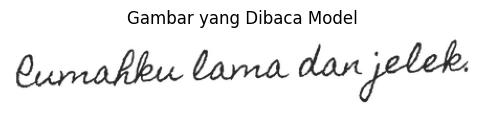

Raw Token IDs dari Model: [2, 0, 20230, 2963, 5657, 1115, 1867, 4764, 5573, 35823, 5, 2]

HASIL DIGITALISASI NOTESCANIN:
Rumahku lama du jelek.


In [16]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

SAMPLE_IMAGE = "sampel_catatan.png"
CHECKPOINT_DIR = "trocr_notescanin_model"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    # 1. Muat ulang model dan processor hasil training
    print("➔ Memuat model NoteScanin hasil fine-tuning...")
    processor = TrOCRProcessor.from_pretrained(CHECKPOINT_DIR)
    model = VisionEncoderDecoderModel.from_pretrained(CHECKPOINT_DIR).to(device)
    model.eval()

    # 2. Buka gambar sampel catatan tulisan tangan
    img = Image.open(SAMPLE_IMAGE).convert("RGB")

    # Menampilkan gambar yang sedang dibaca di notebook
    plt.figure(figsize=(6, 2))
    plt.imshow(img)
    plt.title("Gambar yang Dibaca Model")
    plt.axis("off")
    plt.show()

    # 3. Ekstrak fitur gambar ke format tensor
    pixel_values = processor(images=img, return_tensors="pt").pixel_values.to(device)

    # 4. Proses Generasi Teks Menggunakan Beam Search
    with torch.no_grad():
        generated_ids = model.generate(
            pixel_values,
            max_length=32,
            num_beams=4,          # Menggunakan 4 berkas pencarian agar hasil kata lebih akurat
            early_stopping=True
        )

        # PERBAIKAN: Format pelacakan token ID yang sudah dibersihkan dari typo
        print(f"Raw Token IDs dari Model: {generated_ids[0].tolist()}")

        # Dekode token ID menjadi kalimat teks asli
        hasil_ocr = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    print("\n====================================")
    print("HASIL DIGITALISASI NOTESCANIN:")
    print("====================================")
    if hasil_ocr.strip() == "":
        print("[Hasil Kosong] Model mendeteksi gambar namun belum bisa merangkai kata. Teruskan training!")
    else:
        print(hasil_ocr)
    print("====================================")

except Exception as e:
    print(f"\nGagal menguji model: {e}")